In [108]:
import xarray as xr
import cartopy.crs as ccrs
import numpy as np
import matplotlib.pyplot as plt

In [130]:
base = "/g/data/w97/amu561/CABLE_AWRA_comparison/Drought_metrics"
dataset = "BARPA" # ['BARPA', 'CMIP6', 'CORDEX_CSIRO', 'CORDEX_Qld', 'NARCLIM']
experiment = "historical" # ['historical', 'ssp126', 'ssp370', 'ssp585']
variable = "pr" # ['mrro', 'mrso', 'pr'] # pr = rainfall, mrro = runoff, mrso = soil moisture
drought_threshold = 'Perc_15'
baseline = 'Baseline_1970_2005'
scale = "Scale_3" # ['Scale_3', 'Scale_12']
forcing_gcm = "ACCESS-CM2" # ['ACCESS-CM2', 
#  'CESM2',
#  'CMCC-CMCC-ESM2',
#  'CSIRO-ACCESS-ESM1-5',
#  'CSIRO-ARCCSS-ACCESS-CM2',
#  'EC-Earth-Consortium-EC-Earth3',
#  'EC-Earth3',
#  'MPI-ESM1-2-HR',
#  'MPI-M-MPI-ESM1-2-HR',
#  'NCAR-CESM2',
#  'NCC-NorESM2-MM']
ensemble_member = "r4i1p1f1"
ncfile = "*.nc"

path = base + "/" + dataset + "/" + experiment + "/" +  variable + "/" + drought_threshold + "/" + baseline + "/" + scale + "/" + forcing_gcm + "/" + ensemble_member + "/" + ncfile


In [131]:
variable = "pr"
path_pr = base + "/" + dataset + "/" + experiment + "/" +  variable + "/" + drought_threshold + "/" + baseline + "/" + scale + "/" + forcing_gcm + "/" + ensemble_member + "/" + ncfile
ds_pr = xr.open_mfdataset(path_pr)

In [132]:
variable = "mrso"
path_mrso = base + "/" + dataset + "/" + experiment + "/" +  variable + "/" + drought_threshold + "/" + baseline + "/" + scale + "/" + forcing_gcm + "/" + ensemble_member + "/" + ncfile
ds_mrso = xr.open_mfdataset(path_mrso)

In [133]:
variable = "mrro"
path_mrro = base + "/" + dataset + "/" + experiment + "/" +  variable + "/" + drought_threshold + "/" + baseline + "/" + scale + "/" + forcing_gcm + "/" + ensemble_member + "/" + ncfile
ds_mrro = xr.open_mfdataset(path_mrro)

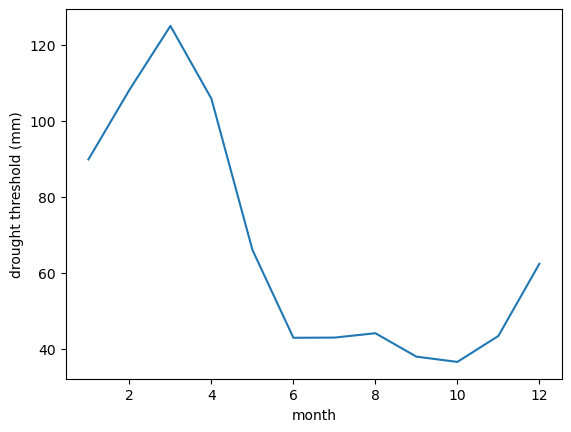

In [134]:
ds_pr.threshold.mean("lat").mean("lon").plot()

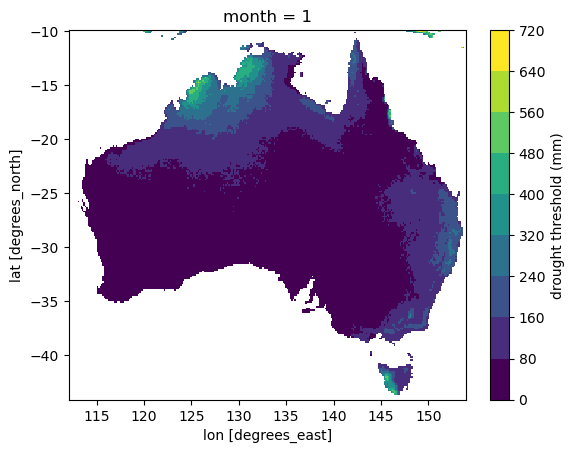

In [135]:
ds_pr.threshold.sel(month = 1).plot(levels=10)


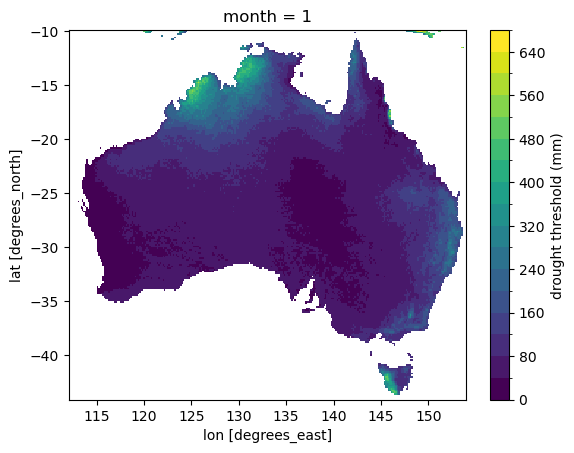

In [127]:
ds_pr.threshold.sel(month = 1).plot(levels=20)


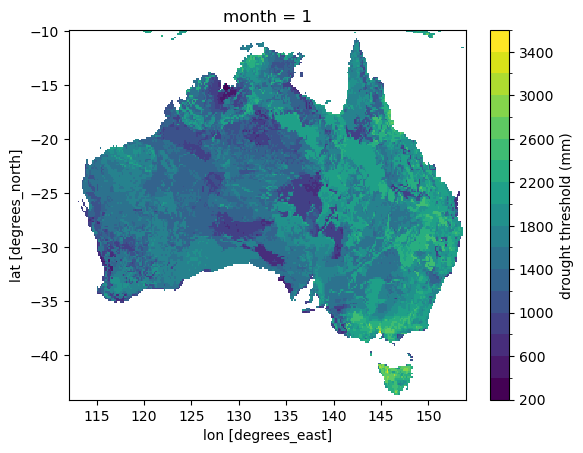

In [128]:
ds_mrso.threshold.sel(month = 1).plot(levels=20)

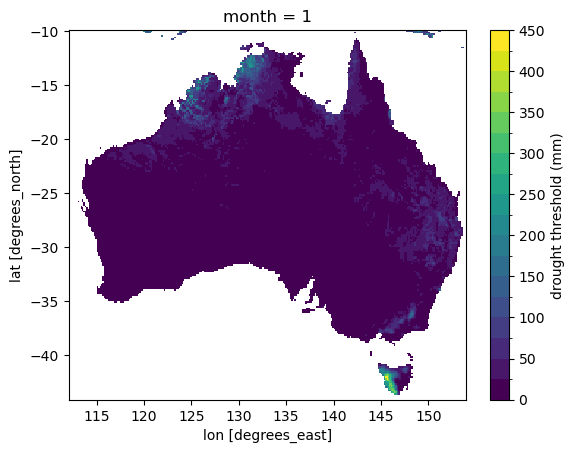

In [136]:
ds_mrro.threshold.sel(month = 1).plot(levels =
                            
                         20)

In [5]:
np.unique(ds.timing.values, return_counts=True)


(array([ 0.,  1., nan]), array([16144707,  3110793, 20272560]))

In [6]:
ds = ds.compute()

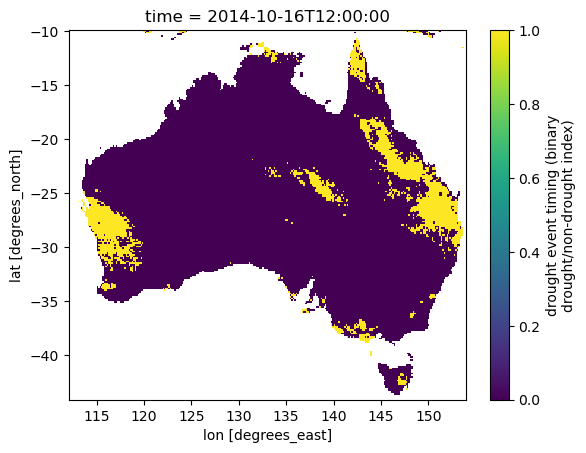

In [34]:
ds.timing.sel(time="10-2014").plot()

In [ ]:
filtered_ds.dropna(dim="timing")

<xarray.DataArray 'timing' (time: 0, lat: 213, lon: 263)> Size: 0B
array([], shape=(0, 213, 263), dtype=float64)
Coordinates:
  * time     (time) datetime64[ns] 0B 
  * lat      (lat) float64 2kB -43.53 -43.38 -43.22 ... -10.32 -10.16 -10.01
  * lon      (lon) float64 2kB 113.1 113.4 113.5 113.7 ... 153.4 153.5 153.7
Attributes:
    long_name:  drought event timing (binary drought/non-drought index)

In [44]:
ds.variables

Frozen({'duration': <xarray.Variable (time: 660, lat: 221, lon: 271)> Size: 316MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
 

In [48]:
ds.where(ds.timing > 0).mean("time").duration

<xarray.DataArray 'duration' (lat: 221, lon: 271)> Size: 479kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(221, 271))
Coordinates:
  * lat      (lat) float64 2kB -44.0 -43.84 -43.69 ... -10.32 -10.16 -10.01
  * lon      (lon) float64 2kB 112.1 112.3 112.4 112.6 ... 153.5 153.7 153.9
Attributes:
    long_name:  drought event duration (no. months)

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)

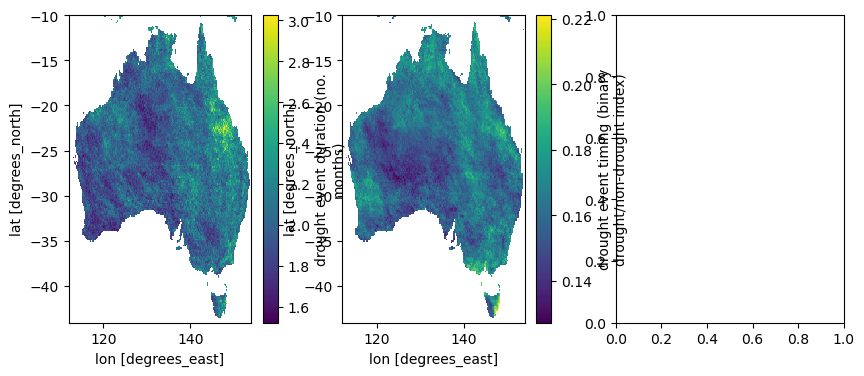

In [47]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))
ds.where(ds.timing > 0).mean("time").duration.plot(ax=ax1
)
ds.mean("time").timing.plot(ax=ax2
)
ds.mean("time").plot(ax=ax3
)

In [43]:
# 1. Set up the figure and map projection
fig = plt.figure(figsize=(10, 6))
# PlateCarree is the standard equirectangular projection
ax = plt.axes(projection=ccrs.PlateCarree()) 

# 2. Add geographic features
ax.coastlines(linewidth=1)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

# 3. Plot the data
# The 'transform' argument is crucial: it tells matplotlib that your 
# data's dimensions (Lon/Lat) are in standard degrees.
ds.mean("time").timing.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
)

plt.title("Mean Timing")
plt.show()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [Errno 101] Network is unreachable>

<Figure size 1000x600 with 2 Axes>